# Hyperbolic Activation Function (Eq. 34) and Connection Weight (Eq.2)

This notebook walks from the paper formula to data mapping and outputs in one place.

## Step 0 — formula and data

Eq. 34 defines the hyperbolic activation

$$
g(z) = \frac{z}{|z|} = \frac{x + u y}{\sqrt{x^2 - y^2}}
$$

This maps a hyperbolic number onto the unit hyperbola (normalization), and is the core nonlinearity of the HHNN model.

Data: plug the \(x\) and \(y\) data into the formula. We use:
- `rating.csv` → average rating per movie (acts as the **x** component; positive magnitude)
- `genome_scores.csv` → tag relevance (acts as the **y** component; semantic signal)

This is the mapping from MovieLens signals into a hyperbolic number \(z = x + u y\), so we can compute the activation step by step.

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

# Resolve project root regardless of where the notebook runs
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_dir = project_root / "data"
print("project_root:", project_root)
print("data_dir:", data_dir)


project_root: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys
data_dir: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/data


## Step 1 — Formula (Eq. 34): Hyperbolic activation

Paper defines hyperbolic number as \(z = x + u y\) with \(u^2 = 1\), and the activation is:

$$
g(z) = \frac{z}{|z|} = \frac{x + u y}{\sqrt{x^2 - y^2}}
$$

We now map MovieLens data into \(x, y\) and compute \(g(z)\) step by step.


In [3]:
# Build a small (x, y) example from data
ratings_path = data_dir / "rating.csv"
if not ratings_path.exists():
    ratings_path = data_dir / "ratings.csv"

scores_path = data_dir / "genome_scores.csv"
if not scores_path.exists():
    raise FileNotFoundError("genome_scores.csv not found")

ratings_df = pd.read_csv(ratings_path, usecols=["movieId", "rating"])
movie_rating = ratings_df.groupby("movieId")["rating"].mean().rename("avg_rating")

scores_df = pd.read_csv(scores_path, usecols=["movieId", "tagId", "relevance"])
# pick one tagId with many entries
tag_id = int(scores_df["tagId"].mode().iloc[0])
score_slice = scores_df[scores_df["tagId"] == tag_id].set_index("movieId")

merged = movie_rating.to_frame().join(score_slice[["relevance"]], how="inner")
merged = merged.sample(n=5, random_state=42)

# x: normalized rating (positive), y: scaled relevance
x = (merged["avg_rating"] / 5.0).values + 0.1
raw_y = merged["relevance"].values

# enforce x^2 > y^2
scale = np.minimum(0.9 * np.abs(x) / (np.abs(raw_y) + 1e-8), 1.0)
y = raw_y * scale

modulus = np.sqrt(np.maximum(x**2 - y**2, 1e-12))

# hyperbolic activation g(z) = z/|z|
gx = x / modulus
gy = y / modulus

print("tagId used:", tag_id)
print("x (rating-based):", x)
print("y (relevance-based):", y)
print("|z|:", modulus)
print("g(z) real part:", gx)
print("g(z) unipotent part:", gy)


tagId used: 1
x (rating-based): [0.64930427 0.80006892 0.80686302 0.60797101 0.71125227]
y (relevance-based): [0.0415  0.03925 0.04775 0.03825 0.04425]
|z|: [0.64797668 0.79910558 0.80544886 0.60676659 0.70987444]
g(z) real part: [1.00204882 1.00120553 1.00175574 1.00198499 1.00194094]
g(z) unipotent part: [0.06404551 0.04911741 0.05928371 0.06303907 0.06233497]


## Step 2 — Result table (movieId, tagId, x, y, g(z))

This shows the concrete numerical values after applying the formula.

In [4]:
result_df = merged.copy()
result_df["x"] = x
result_df["y"] = y
result_df["modulus"] = modulus
result_df["g_real"] = gx
result_df["g_unipotent"] = gy
result_df.insert(0, "tagId", tag_id)
result_df.reset_index(inplace=True)

result_df

,movieId,tagId,avg_rating,relevance,x,y,modulus,g_real,g_unipotent
0,63992,1,2.746521,0.04150,0.649304,0.04150,0.647977,1.002049,0.064046
1,339,1,3.500345,0.03925,0.800069,0.03925,0.799106,1.001206,0.049117
2,34162,1,3.534315,0.04775,0.806863,0.04775,0.805449,1.001756,0.059284
3,54278,1,2.539855,0.03825,0.607971,0.03825,0.606767,1.001985,0.063039
4,3399,1,3.056261,0.04425,0.711252,0.04425,0.709874,1.001941,0.062335


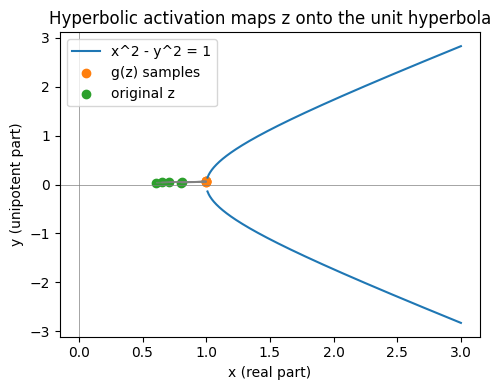

In [5]:
# Step 2b — Plot hyperbola x^2 - y^2 = 1 and mapping arrows
import matplotlib.pyplot as plt

# Hyperbola curve (right branch)
x_curve = np.linspace(1.01, 3.0, 400)
y_curve = np.sqrt(x_curve**2 - 1)

g_x = result_df["g_real"].values
g_y = result_df["g_unipotent"].values

# Original points (x, y) before normalization
orig_x = result_df["x"].values
orig_y = result_df["y"].values

plt.figure(figsize=(5, 4))
plt.plot(x_curve, y_curve, label="x^2 - y^2 = 1")
plt.plot(x_curve, -y_curve, color="C0")
plt.scatter(g_x, g_y, color="C1", label="g(z) samples")
plt.scatter(orig_x, orig_y, color="C2", label="original z")

# Arrows showing z -> g(z)
for ox, oy, gx_i, gy_i in zip(orig_x, orig_y, g_x, g_y):
    plt.arrow(ox, oy, gx_i - ox, gy_i - oy, color="gray", alpha=0.6, width=0.0, head_width=0.02, length_includes_head=True)

plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.xlabel("x (real part)")
plt.ylabel("y (unipotent part)")
plt.title("Hyperbolic activation maps z onto the unit hyperbola")
plt.legend()
plt.tight_layout()
plt.show()

The arrows show how each data-derived point \(z\) is normalized by Eq. 34 onto the unit hyperbola, so the activation outputs lie on a constrained manifold.

## Step 3 — Connection weights (Hebbian rule)

Paper uses:

```math
w_{kj} = \sum_p c_k^p \, c_j^p
```

We treat each **movie** as a pattern \(p\), and each **tag** as a neuron \(k\). We compute hyperbolic states \(c_k^p\) from MovieLens data using Eq. 34

Then we sum hyperbolic products across movies to get a weight matrix between tags.

In [6]:
# Build movie-movie connection weights using symmetry
# Ensure data_dir exists (in case earlier cells were skipped)
if "data_dir" not in globals():
    from pathlib import Path
    project_root = Path.cwd().resolve()
    if project_root.name == "notebooks":
        project_root = project_root.parent
    data_dir = project_root / "data"

# Load movies for genres and titles
movies_path = data_dir / "movies.csv"
if not movies_path.exists():
    movies_path = data_dir / "movie.csv"
if not movies_path.exists():
    raise FileNotFoundError("movies.csv (or movie.csv) not found")

movies_df = pd.read_csv(movies_path, usecols=["movieId", "title", "genres"]).drop_duplicates("movieId")
movies_df = movies_df.set_index("movieId")

# Tag relevance (semantic features)
scores_df = pd.read_csv(scores_path, usecols=["movieId", "tagId", "relevance"])
_top_tags = scores_df["tagId"].value_counts().head(20).index.tolist()
score_subset = scores_df[scores_df["tagId"].isin(_top_tags)]
score_pivot = score_subset.pivot_table(index="movieId", columns="tagId", values="relevance", fill_value=0.0)

# Align movies with both genres and tags, then sample for visualization
common_ids = score_pivot.index.intersection(movies_df.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping movieId between movies and genome_scores")

sample_n = min(200, len(common_ids))
movie_ids = common_ids.to_series().sample(n=sample_n, random_state=42).values
score_pivot = score_pivot.loc[movie_ids]

# Genres (content features)
genres_series = movies_df.loc[movie_ids, "genres"].fillna("(no genres listed)")
all_genres = sorted({g for gs in genres_series for g in str(gs).split("|")})
genre_index = {g: i for i, g in enumerate(all_genres)}

genre_matrix = np.zeros((len(movie_ids), len(all_genres)), dtype=float)
for i, gs in enumerate(genres_series):
    for g in str(gs).split("|"):
        genre_matrix[i, genre_index[g]] = 1.0

# Feature matrix = [genres one-hot | tag relevance]
tag_matrix = score_pivot.values
features = np.hstack([genre_matrix, tag_matrix])

# Cosine similarity (symmetric weights)
norm = np.linalg.norm(features, axis=1, keepdims=True)
norm[norm == 0] = 1.0
features_norm = features / norm
W = features_norm @ features_norm.T

movie_titles = movies_df.loc[movie_ids, "title"].tolist()

print("movies used:", len(movie_ids))
print("tags used:", len(_top_tags))
print("genres used:", len(all_genres))


movies used: 200
tags used: 12


### Full view across selected movies

Below we list the top connections for **every movie** in this subset (not just one example).

In [7]:
# List top connections for all movies in the subset
rows = []
for i, mid in enumerate(movie_ids):
    weights = W[i].copy()
    weights[i] = -1.0  # exclude self
    top_idx = np.argsort(weights)[::-1][:5]
    for rank, j in enumerate(top_idx, start=1):
        rows.append({
            "movieId": int(mid),
            "title": movie_titles[i],
            "rank": rank,
            "connected_movieId": int(movie_ids[j]),
            "connected_title": movie_titles[j],
            "weight": float(weights[j]),
        })

full_view_df = pd.DataFrame(rows)
full_view_df

,tagId,tag,rank,connected_tagId,connected_tag,W_real
0,1,007,1,754,oscar (best music - original score),251.567823
1,1,007,2,750,oscar (best directing),243.069120
2,1,007,3,751,oscar (best editing),221.761094
3,1,007,4,748,oscar (best animated feature),214.038724
4,1,007,5,755,oscar (best music - original song),213.903876
5,750,oscar (best directing),1,750,oscar (best directing),406.341958
6,750,oscar (best directing),2,754,oscar (best music - original score),401.237906
7,750,oscar (best directing),3,751,oscar (best editing),303.162426
8,750,oscar (best directing),4,748,oscar (best animated feature),292.350364
9,750,oscar (best directing),5,755,oscar (best music - original song),288.805650


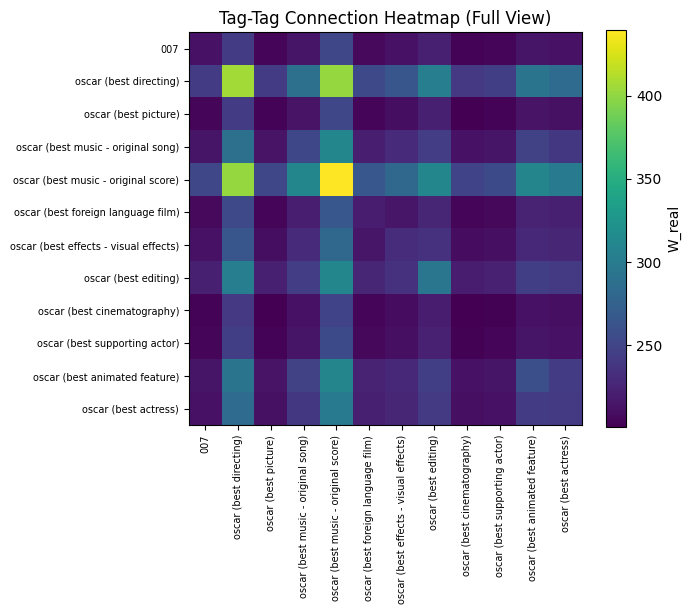

In [8]:
# Full view heatmap for selected movies
plt.figure(figsize=(7, 6))
plt.imshow(W, cmap="viridis")
plt.colorbar(label="weight")

if len(movie_titles) <= 40:
    labels = movie_titles
    plt.xticks(range(len(labels)), labels, rotation=90, fontsize=6)
    plt.yticks(range(len(labels)), labels, fontsize=6)
    plt.title("Movie-Movie Connection Heatmap (labels shown)")
else:
    plt.title("Movie-Movie Connection Heatmap (labels hidden for readability)")

plt.tight_layout()
plt.show()

This heatmap visualizes movie–movie resonance scores. Brighter cells indicate pairs of movies that are more similar in genres and tag relevance, supporting symmetric connections and stable energy convergence.